# Optimize the bT Mixture Fit

This notebook tests several ways to improve the constrained `bT = (1 - c1)*b0 + c1*b1` fit uncertainty.

It uses the same double-511 gate idea as the previous notebooks: require the two back-to-back HPGe detectors, `HPGe_1` and `HPGe_2`, to be near 511 keV and ignore `HPGe_3`.

The main outputs are:
- A ratio fit, `bT/b0 = 1 + c1*(b1/b0 - 1)`.
- A sensitivity plot showing which Si(Li) sum bins actually constrain `c1`.
- Fit-window and HPGe-gate scans.
- A 2D fit using `(SiLi_1, SiLi_2)` rather than only the sum.
- A template-statistics diagnostic and projected uncertainty improvement from larger `b0`/`b1` samples.

In [1]:
# Setup
from __future__ import annotations

from pathlib import Path
import os

_cache_root = Path.cwd() / "tmp" / "notebook_cache"
(_cache_root / "matplotlib").mkdir(parents=True, exist_ok=True)
(_cache_root / "xdg").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_cache_root / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(_cache_root / "xdg"))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Configuration

The broad HPGe gate is collected once and reused for narrower gate scans. The default fit window avoids the distorted low-energy region and stops at the physical endpoint.

In [2]:
REPO = Path.cwd().resolve()
if REPO.name == "analysis":
    REPO = REPO.parent
elif REPO.name == "notebooks":
    REPO = REPO.parent.parent

OUTPUT_DIR = REPO / "output"
FIG_DIR = OUTPUT_DIR / "notebook_figures" / "optimize_bT_mixture_fit"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "b0": OUTPUT_DIR / "22Na_b0.parquet",
    "b1": OUTPUT_DIR / "22Na_b1.parquet",
    "bT": OUTPUT_DIR / "22Na_b25.parquet",
}
for label, path in FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

HPGE_511_KEV = 511.0
DEFAULT_GATE_HALF_WIDTH = 3.0
GATE_HALF_WIDTHS = [2.0, 3.0, 4.0, 5.0, 7.0, 10.0]
MAX_GATE_HALF_WIDTH = max(GATE_HALF_WIDTHS)

SILI_RANGE = (0.0, 700.0)
FIT_RANGE = (100.0, 545.0)
FIT_WINDOWS = [
    (100.0, 545.0),
    (125.0, 545.0),
    (150.0, 545.0),
    (175.0, 545.0),
    (200.0, 545.0),
    (250.0, 545.0),
    (100.0, 500.0),
    (150.0, 500.0),
    (200.0, 500.0),
]
BIN_WIDTH = 2.0
BINS = np.arange(SILI_RANGE[0], SILI_RANGE[1] + BIN_WIDTH, BIN_WIDTH)
CENTERS = 0.5 * (BINS[:-1] + BINS[1:])

SILI_2D_RANGE = (0.0, 650.0)
BIN_WIDTH_2D = 10.0
BINS_2D = np.arange(SILI_2D_RANGE[0], SILI_2D_RANGE[1] + BIN_WIDTH_2D, BIN_WIDTH_2D)
CENTERS_2D = 0.5 * (BINS_2D[:-1] + BINS_2D[1:])

RNG_SEED = 20240622

print(f"Repository: {REPO}")
print(f"Figures: {FIG_DIR}")
print(f"Default HPGe gate: 511 +/- {DEFAULT_GATE_HALF_WIDTH:g} keV")
print(f"Default fit range: {FIT_RANGE[0]:g}-{FIT_RANGE[1]:g} keV")

def savefig(fig: plt.Figure, name: str) -> None:
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(path)

Repository: /Users/ronguy/Code/BpSpec/DualSiLi22Na
Figures: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit
Default HPGe gate: 511 +/- 3 keV
Default fit range: 100-545 keV


## Load a Broad HPGe-Gated Sample

This reads only the columns needed for all later studies. The broad `±10 keV` HPGe gate makes the later gate-width scan cheap because narrower gates are applied in memory.

In [3]:
def scan_broad_gate(path: Path) -> pl.LazyFrame:
    lo = HPGE_511_KEV - MAX_GATE_HALF_WIDTH
    hi = HPGE_511_KEV + MAX_GATE_HALF_WIDTH
    return (
        pl.scan_parquet(path)
        .select(
            "E_SiLi_1_keV",
            "E_SiLi_2_keV",
            "E_SiLi_sum_keV",
            "E_HPGe_1_keV",
            "E_HPGe_2_keV",
            "event_weight",
        )
        .filter(
            (pl.col("E_HPGe_1_keV").is_between(lo, hi, closed="both"))
            & (pl.col("E_HPGe_2_keV").is_between(lo, hi, closed="both"))
            & (pl.col("E_SiLi_sum_keV") > 0)
            & (pl.col("E_SiLi_sum_keV").is_between(SILI_RANGE[0], SILI_RANGE[1], closed="left"))
        )
    )

samples = {label: scan_broad_gate(path).collect() for label, path in FILES.items()}
load_summary = pl.DataFrame([
    {
        "spectrum": label,
        "broad_gate_rows": len(df),
        "weighted_rows": float(df["event_weight"].sum()),
    }
    for label, df in samples.items()
])
load_summary

spectrum,broad_gate_rows,weighted_rows
str,i64,f64
"""b0""",852356,852356.0
"""b1""",854831,854831.0
"""bT""",853523,853523.0


## Histogram and Fit Helpers

The fit is always constrained to one coefficient: `c0 = 1 - c1`. Histogram variances use `sum(w^2)` so weighted parquet files work as well as unweighted files.

In [4]:
def gate_sample(df: pl.DataFrame, gate_half_width: float) -> pl.DataFrame:
    lo = HPGE_511_KEV - gate_half_width
    hi = HPGE_511_KEV + gate_half_width
    return df.filter(
        (pl.col("E_HPGe_1_keV").is_between(lo, hi, closed="both"))
        & (pl.col("E_HPGe_2_keV").is_between(lo, hi, closed="both"))
    )


def hist1d(df: pl.DataFrame, gate_half_width: float, bins: np.ndarray = BINS) -> tuple[np.ndarray, np.ndarray, int]:
    g = gate_sample(df, gate_half_width)
    e = g["E_SiLi_sum_keV"].to_numpy()
    w = g["event_weight"].cast(pl.Float64).to_numpy()
    h, _ = np.histogram(e, bins=bins, weights=w)
    v, _ = np.histogram(e, bins=bins, weights=w * w)
    return h.astype(float), v.astype(float), len(g)


def hist2d(df: pl.DataFrame, gate_half_width: float, bins: np.ndarray = BINS_2D) -> tuple[np.ndarray, np.ndarray, int]:
    g = gate_sample(df, gate_half_width)
    e1 = g["E_SiLi_1_keV"].to_numpy()
    e2 = g["E_SiLi_2_keV"].to_numpy()
    w = g["event_weight"].cast(pl.Float64).to_numpy()
    h, _, _ = np.histogram2d(e1, e2, bins=[bins, bins], weights=w)
    v, _, _ = np.histogram2d(e1, e2, bins=[bins, bins], weights=w * w)
    return h.astype(float), v.astype(float), len(g)


def fit_mask_for_window(window: tuple[float, float], centers: np.ndarray = CENTERS) -> np.ndarray:
    return (centers >= window[0]) & (centers <= window[1])


def normalize_in_mask(h: np.ndarray, v: np.ndarray, mask: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    total = float(np.sum(h[mask]))
    if total <= 0:
        raise ValueError("Empty normalization window")
    return h / total, v / (total * total), total


def constrained_fit(y: np.ndarray, a: np.ndarray, b: np.ndarray, sigma: np.ndarray, mask: np.ndarray | None = None) -> dict:
    if mask is None:
        mask = np.ones_like(y, dtype=bool)
    good = mask & np.isfinite(y) & np.isfinite(a) & np.isfinite(b) & np.isfinite(sigma) & (sigma > 0)
    yy = y[good]
    aa = a[good]
    bb = b[good]
    ss = sigma[good]
    delta = bb - aa
    resid0 = yy - aa
    weight = 1.0 / ss**2
    denom = float(np.sum(weight * delta**2))
    if denom <= 0:
        raise ValueError("No sensitivity: b0 and b1 are indistinguishable in selected bins")
    c1 = float(np.sum(weight * delta * resid0) / denom)
    c1_err = float(np.sqrt(1.0 / denom))
    model = a + c1 * (b - a)
    pull = (yy - model[good]) / ss
    chi2 = float(np.sum(pull**2))
    dof = max(1, int(np.count_nonzero(good)) - 1)
    return {
        "c1": c1,
        "c0": 1.0 - c1,
        "c1_err": c1_err,
        "c0_err": c1_err,
        "model": model,
        "chi2": chi2,
        "dof": dof,
        "chi2_ndf": chi2 / dof,
        "mask": good,
        "pull": pull,
    }


def ratio_fit(
    h0: np.ndarray,
    v0: np.ndarray,
    h1: np.ndarray,
    v1: np.ndarray,
    hT: np.ndarray,
    vT: np.ndarray,
    mask: np.ndarray,
    include_template_stats: bool = False,
    template_stat_scale: float = 1.0,
    iterations: int = 4,
) -> dict:
    p0, vp0, n0 = normalize_in_mask(h0, v0 / template_stat_scale, mask)
    p1, vp1, n1 = normalize_in_mask(h1, v1 / template_stat_scale, mask)
    pT, vpT, nT = normalize_in_mask(hT, vT, mask)

    good = mask & (p0 > 0) & (p1 > 0) & (pT > 0)
    rT0 = np.full_like(pT, np.nan, dtype=float)
    r10 = np.full_like(pT, np.nan, dtype=float)
    srT0 = np.full_like(pT, np.nan, dtype=float)
    sr10 = np.full_like(pT, np.nan, dtype=float)
    rT0[good] = pT[good] / p0[good]
    r10[good] = p1[good] / p0[good]
    srT0[good] = np.abs(rT0[good]) * np.sqrt(vpT[good] / pT[good] ** 2 + vp0[good] / p0[good] ** 2)
    sr10[good] = np.abs(r10[good]) * np.sqrt(vp1[good] / p1[good] ** 2 + vp0[good] / p0[good] ** 2)

    x = r10 - 1.0
    y = rT0 - 1.0
    sigma = srT0.copy()
    fit = None
    for _ in range(iterations if include_template_stats else 1):
        fit = constrained_fit(y, np.zeros_like(y), x, sigma, good)
        if include_template_stats:
            sigma = np.sqrt(srT0**2 + (fit["c1"] * sr10) ** 2)
    fit = constrained_fit(y, np.zeros_like(y), x, sigma, good)
    fit.update({
        "rT0": rT0,
        "r10": r10,
        "sigma_rT0": srT0,
        "sigma_r10": sr10,
        "sigma_used": sigma,
        "sensitivity": np.where(good, np.abs(x) / sigma, np.nan),
        "good": good,
        "n0_fit": n0,
        "n1_fit": n1,
        "nT_fit": nT,
    })
    return fit


def shape_fit(h0: np.ndarray, v0: np.ndarray, h1: np.ndarray, v1: np.ndarray, hT: np.ndarray, vT: np.ndarray, mask: np.ndarray) -> dict:
    p0, vp0, n0 = normalize_in_mask(h0, v0, mask)
    p1, vp1, n1 = normalize_in_mask(h1, v1, mask)
    pT, vpT, nT = normalize_in_mask(hT, vT, mask)
    sigma = np.sqrt(np.maximum(vpT, 1e-30))
    fit = constrained_fit(pT, p0, p1, sigma, mask & (pT > 0) & (p0 > 0) & (p1 > 0))
    fit.update({"p0": p0, "p1": p1, "pT": pT, "sigma": sigma, "n0_fit": n0, "n1_fit": n1, "nT_fit": nT})
    return fit

## Convert Template Coefficient to Physical Fierz b

The fitted `c1` is the coordinate between normalized `b=0` and `b=1` templates, not the physical Fierz `b`. The cell below calibrates the nonlinear normalization mapping using raw closure spectra such as `22Na_25.raw`.

In [5]:
def read_raw_spectrum(path: Path) -> tuple[np.ndarray, np.ndarray]:
    energy = []
    rate = []
    with path.open() as f:
        for line in f:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            energy.append(float(parts[1]))
            rate.append(float(parts[2]))
    return np.asarray(energy), np.asarray(rate)


def normalized_template_coordinate(target: np.ndarray, b0: np.ndarray, b1: np.ndarray, mask: np.ndarray) -> float:
    def norm(y: np.ndarray) -> np.ndarray:
        return y / np.sum(y[mask])
    pT = norm(target)
    p0 = norm(b0)
    p1 = norm(b1)
    delta = p1[mask] - p0[mask]
    resid = pT[mask] - p0[mask]
    return float(np.sum(delta * resid) / np.sum(delta * delta))


def infer_G_from_closure(physical_b: float, template_c: float) -> float:
    return float((physical_b - template_c) / (physical_b * (template_c - 1.0)))


def physical_b_from_template_c(template_c: float, G: float) -> float:
    return float(template_c / (1.0 + G * (1.0 - template_c)))


def physical_b_error_from_template_c(template_c: float, template_c_err: float, G: float) -> float:
    denom = 1.0 + G * (1.0 - template_c)
    derivative = (1.0 + G) / (denom * denom)
    return float(abs(derivative) * template_c_err)

raw_fit_mask = fit_mask_for_window(FIT_RANGE) if "fit_mask_for_window" in globals() else FIT_MASK
raw_energy, raw_b0 = read_raw_spectrum(REPO / "22Na_0.raw")
_, raw_b1 = read_raw_spectrum(REPO / "22Na_1.raw")
raw_mask = (raw_energy >= FIT_RANGE[0]) & (raw_energy <= FIT_RANGE[1])

closure_inputs = []
for physical_b, raw_name in [(0.05, "22Na_05.raw"), (0.25, "22Na_25.raw")]:
    raw_path = REPO / raw_name
    if raw_path.exists():
        _, raw_target = read_raw_spectrum(raw_path)
        template_c = normalized_template_coordinate(raw_target, raw_b0, raw_b1, raw_mask)
        closure_inputs.append({
            "raw_file": raw_name,
            "physical_b": physical_b,
            "template_c": template_c,
            "inferred_G": infer_G_from_closure(physical_b, template_c),
            "roundtrip_physical_b": physical_b_from_template_c(template_c, infer_G_from_closure(physical_b, template_c)),
        })

fierz_G = float(np.mean([row["inferred_G"] for row in closure_inputs]))
fierz_mapping_table = pl.DataFrame(closure_inputs)
print(f"Fierz normalization mapping G = {fierz_G:.6f}")
fierz_mapping_table

Fierz normalization mapping G = 0.684584


raw_file,physical_b,template_c,inferred_G,roundtrip_physical_b
str,f64,f64,f64,f64
"""22Na_05.raw""",0.05,0.081441,0.684582,0.05
"""22Na_25.raw""",0.25,0.359602,0.684587,0.25


## Baseline Ratio Fit and Sensitivity

The ratio fit removes absolute normalization and fits the distortion directly:

`bT/b0 = 1 + c1 * (b1/b0 - 1)`.

The sensitivity panel shows where the fit is actually getting information.

In [6]:
hists = {}
for label in ["b0", "b1", "bT"]:
    h, v, n = hist1d(samples[label], DEFAULT_GATE_HALF_WIDTH)
    hists[label] = {"h": h, "v": v, "n": n}

fit_mask = fit_mask_for_window(FIT_RANGE)
baseline_ratio = ratio_fit(
    hists["b0"]["h"], hists["b0"]["v"],
    hists["b1"]["h"], hists["b1"]["v"],
    hists["bT"]["h"], hists["bT"]["v"],
    fit_mask,
    include_template_stats=False,
)
baseline_ratio_with_templates = ratio_fit(
    hists["b0"]["h"], hists["b0"]["v"],
    hists["b1"]["h"], hists["b1"]["v"],
    hists["bT"]["h"], hists["bT"]["v"],
    fit_mask,
    include_template_stats=True,
)
baseline_shape = shape_fit(
    hists["b0"]["h"], hists["b0"]["v"],
    hists["b1"]["h"], hists["b1"]["v"],
    hists["bT"]["h"], hists["bT"]["v"],
    fit_mask,
)

baseline_summary = pl.DataFrame([
    {
        "fit": "ratio_target_and_b0_stats",
        "c1": baseline_ratio["c1"],
        "c1_err": baseline_ratio["c1_err"],
        "c0": baseline_ratio["c0"],
        "chi2_ndf": baseline_ratio["chi2_ndf"],
        "n_fit_bins": int(np.count_nonzero(baseline_ratio["mask"])),
    },
    {
        "fit": "ratio_with_template_stats",
        "c1": baseline_ratio_with_templates["c1"],
        "c1_err": baseline_ratio_with_templates["c1_err"],
        "c0": baseline_ratio_with_templates["c0"],
        "chi2_ndf": baseline_ratio_with_templates["chi2_ndf"],
        "n_fit_bins": int(np.count_nonzero(baseline_ratio_with_templates["mask"])),
    },
    {
        "fit": "normalized_shape",
        "c1": baseline_shape["c1"],
        "c1_err": baseline_shape["c1_err"],
        "c0": baseline_shape["c0"],
        "chi2_ndf": baseline_shape["chi2_ndf"],
        "n_fit_bins": int(np.count_nonzero(baseline_shape["mask"])),
    },
])
baseline_summary

fit,c1,c1_err,c0,chi2_ndf,n_fit_bins
str,f64,f64,f64,f64,i64
"""ratio_target_and_b0_stats""",0.404899,0.032366,0.595101,0.796143,220
"""ratio_with_template_stats""",0.403953,0.034863,0.596047,0.684255,220
"""normalized_shape""",0.403389,0.022966,0.596611,1.574677,220


/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/ratio_fit_and_sensitivity.png


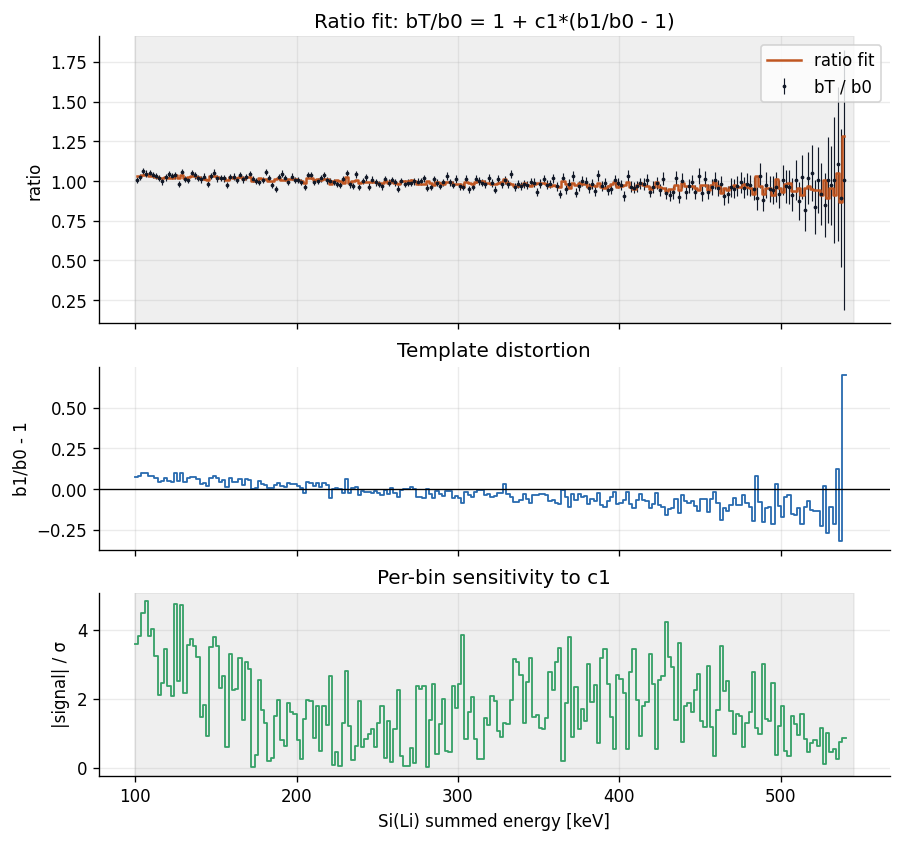

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8.5, 8), sharex=True, height_ratios=[2.2, 1.4, 1.4])
ax = axes[0]
ax.errorbar(
    CENTERS[baseline_ratio["good"]],
    baseline_ratio["rT0"][baseline_ratio["good"]],
    yerr=baseline_ratio["sigma_rT0"][baseline_ratio["good"]],
    fmt=".",
    markersize=2.5,
    linewidth=0.7,
    color="#111827",
    label="bT / b0",
)
model_ratio = 1.0 + baseline_ratio["c1"] * (baseline_ratio["r10"] - 1.0)
ax.step(CENTERS[baseline_ratio["good"]], model_ratio[baseline_ratio["good"]], where="mid", color="#c05621", linewidth=1.5, label="ratio fit")
ax.axvspan(FIT_RANGE[0], FIT_RANGE[1], color="grey", alpha=0.12)
ax.set_ylabel("ratio")
ax.set_title("Ratio fit: bT/b0 = 1 + c1*(b1/b0 - 1)")
ax.legend()

axes[1].step(CENTERS, baseline_ratio["r10"] - 1.0, where="mid", color="#2b6cb0", linewidth=1.1)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("b1/b0 - 1")
axes[1].set_title("Template distortion")

axes[2].step(CENTERS, baseline_ratio["sensitivity"], where="mid", color="#38a169", linewidth=1.1)
axes[2].axvspan(FIT_RANGE[0], FIT_RANGE[1], color="grey", alpha=0.12)
axes[2].set_xlabel("Si(Li) summed energy [keV]")
axes[2].set_ylabel("|signal| / σ")
axes[2].set_title("Per-bin sensitivity to c1")
savefig(fig, "ratio_fit_and_sensitivity.png")
plt.show()

## Fit-Window Scan

This tests whether low-energy distortions or endpoint-region bins are driving the uncertainty or bias.

In [8]:
window_rows = []
for window in FIT_WINDOWS:
    mask = fit_mask_for_window(window)
    rf = ratio_fit(
        hists["b0"]["h"], hists["b0"]["v"],
        hists["b1"]["h"], hists["b1"]["v"],
        hists["bT"]["h"], hists["bT"]["v"],
        mask,
        include_template_stats=True,
    )
    sf = shape_fit(
        hists["b0"]["h"], hists["b0"]["v"],
        hists["b1"]["h"], hists["b1"]["v"],
        hists["bT"]["h"], hists["bT"]["v"],
        mask,
    )
    window_rows.append({
        "fit_min_keV": window[0],
        "fit_max_keV": window[1],
        "ratio_c1": rf["c1"],
        "ratio_c1_err": rf["c1_err"],
        "ratio_chi2_ndf": rf["chi2_ndf"],
        "ratio_bins": int(np.count_nonzero(rf["mask"])),
        "shape_c1": sf["c1"],
        "shape_c1_err": sf["c1_err"],
        "shape_chi2_ndf": sf["chi2_ndf"],
    })
window_scan = pl.DataFrame(window_rows)
window_scan

fit_min_keV,fit_max_keV,ratio_c1,ratio_c1_err,ratio_chi2_ndf,ratio_bins,shape_c1,shape_c1_err,shape_chi2_ndf
f64,f64,f64,f64,f64,i64,f64,f64,f64
100.0,545.0,0.403953,0.034863,0.684255,220,0.403389,0.022966,1.574677
125.0,545.0,0.392613,0.038032,0.701448,208,0.391923,0.025161,1.601621
150.0,545.0,0.383339,0.043341,0.703428,195,0.382294,0.028801,1.5956
175.0,545.0,0.374578,0.049383,0.728236,183,0.373629,0.03295,1.643181
200.0,545.0,0.382423,0.055744,0.641042,170,0.381485,0.037095,1.451011
250.0,545.0,0.332918,0.070947,0.610794,145,0.329976,0.04808,1.335772
100.0,500.0,0.40713,0.035228,0.729089,200,0.406621,0.023178,1.68324
150.0,500.0,0.387844,0.043946,0.7566,175,0.386903,0.029156,1.723236
200.0,500.0,0.389963,0.056844,0.693803,150,0.389217,0.037729,1.580323


/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/fit_window_scan.png


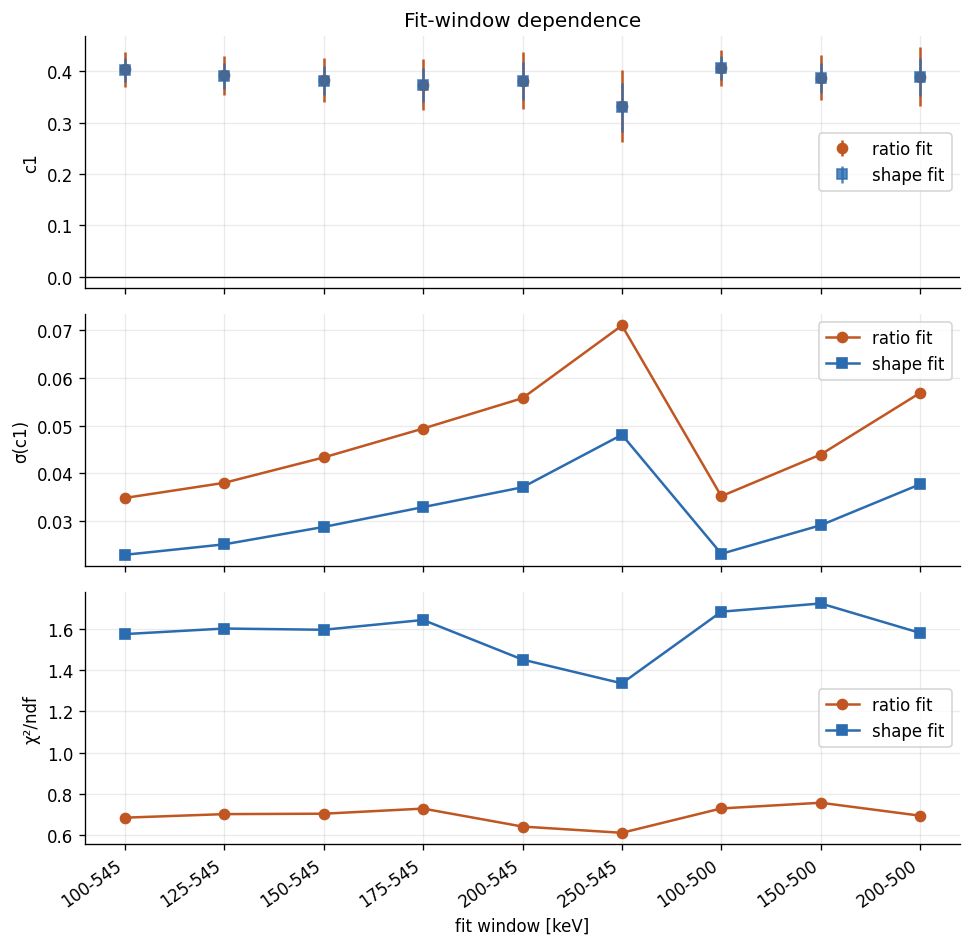

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(8.2, 8), sharex=True)
labels = [f"{int(a)}-{int(b)}" for a, b in zip(window_scan["fit_min_keV"], window_scan["fit_max_keV"])]
x = np.arange(len(labels))
axes[0].errorbar(x, window_scan["ratio_c1"], yerr=window_scan["ratio_c1_err"], fmt="o", color="#c05621", label="ratio fit")
axes[0].errorbar(x, window_scan["shape_c1"], yerr=window_scan["shape_c1_err"], fmt="s", color="#2b6cb0", label="shape fit", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("c1")
axes[0].legend()
axes[0].set_title("Fit-window dependence")

axes[1].plot(x, window_scan["ratio_c1_err"], "o-", color="#c05621", label="ratio fit")
axes[1].plot(x, window_scan["shape_c1_err"], "s-", color="#2b6cb0", label="shape fit")
axes[1].set_ylabel("σ(c1)")
axes[1].legend()

axes[2].plot(x, window_scan["ratio_chi2_ndf"], "o-", color="#c05621", label="ratio fit")
axes[2].plot(x, window_scan["shape_chi2_ndf"], "s-", color="#2b6cb0", label="shape fit")
axes[2].set_ylabel("χ²/ndf")
axes[2].set_xlabel("fit window [keV]")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=35, ha="right")
axes[2].legend()
fig.tight_layout()
savefig(fig, "fit_window_scan.png")
plt.show()

## HPGe Gate-Width Scan

This tests whether a tighter or looser 511 keV gate improves precision. The best gate is the one that minimizes `σ(c1)` while keeping `χ²/ndf` stable.

In [10]:
gate_rows = []
for half_width in GATE_HALF_WIDTHS:
    local_hists = {}
    for label in ["b0", "b1", "bT"]:
        h, v, n = hist1d(samples[label], half_width)
        local_hists[label] = {"h": h, "v": v, "n": n}
    rf = ratio_fit(
        local_hists["b0"]["h"], local_hists["b0"]["v"],
        local_hists["b1"]["h"], local_hists["b1"]["v"],
        local_hists["bT"]["h"], local_hists["bT"]["v"],
        fit_mask,
        include_template_stats=True,
    )
    sf = shape_fit(
        local_hists["b0"]["h"], local_hists["b0"]["v"],
        local_hists["b1"]["h"], local_hists["b1"]["v"],
        local_hists["bT"]["h"], local_hists["bT"]["v"],
        fit_mask,
    )
    gate_rows.append({
        "gate_half_width_keV": half_width,
        "b0_gated_events": local_hists["b0"]["n"],
        "b1_gated_events": local_hists["b1"]["n"],
        "bT_gated_events": local_hists["bT"]["n"],
        "ratio_c1": rf["c1"],
        "ratio_c1_err": rf["c1_err"],
        "ratio_chi2_ndf": rf["chi2_ndf"],
        "shape_c1": sf["c1"],
        "shape_c1_err": sf["c1_err"],
        "shape_chi2_ndf": sf["chi2_ndf"],
    })
gate_scan = pl.DataFrame(gate_rows)
gate_scan

gate_half_width_keV,b0_gated_events,b1_gated_events,bT_gated_events,ratio_c1,ratio_c1_err,ratio_chi2_ndf,shape_c1,shape_c1_err,shape_chi2_ndf
f64,i64,i64,i64,f64,f64,f64,f64,f64,f64
2.0,837528,839834,838674,0.404145,0.034904,0.682323,0.403605,0.022992,1.5703
3.0,839410,841710,840513,0.403953,0.034863,0.684255,0.403389,0.022966,1.574677
4.0,841282,843532,842313,0.405318,0.034863,0.687061,0.404745,0.022955,1.582498
5.0,843148,845427,844201,0.407007,0.034855,0.694548,0.406396,0.022938,1.601476
7.0,846869,849075,847941,0.408255,0.034841,0.695532,0.407658,0.02292,1.60514
10.0,852356,854831,853523,0.40658,0.034688,0.692599,0.40591,0.022832,1.596033


/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/hpge_gate_width_scan.png


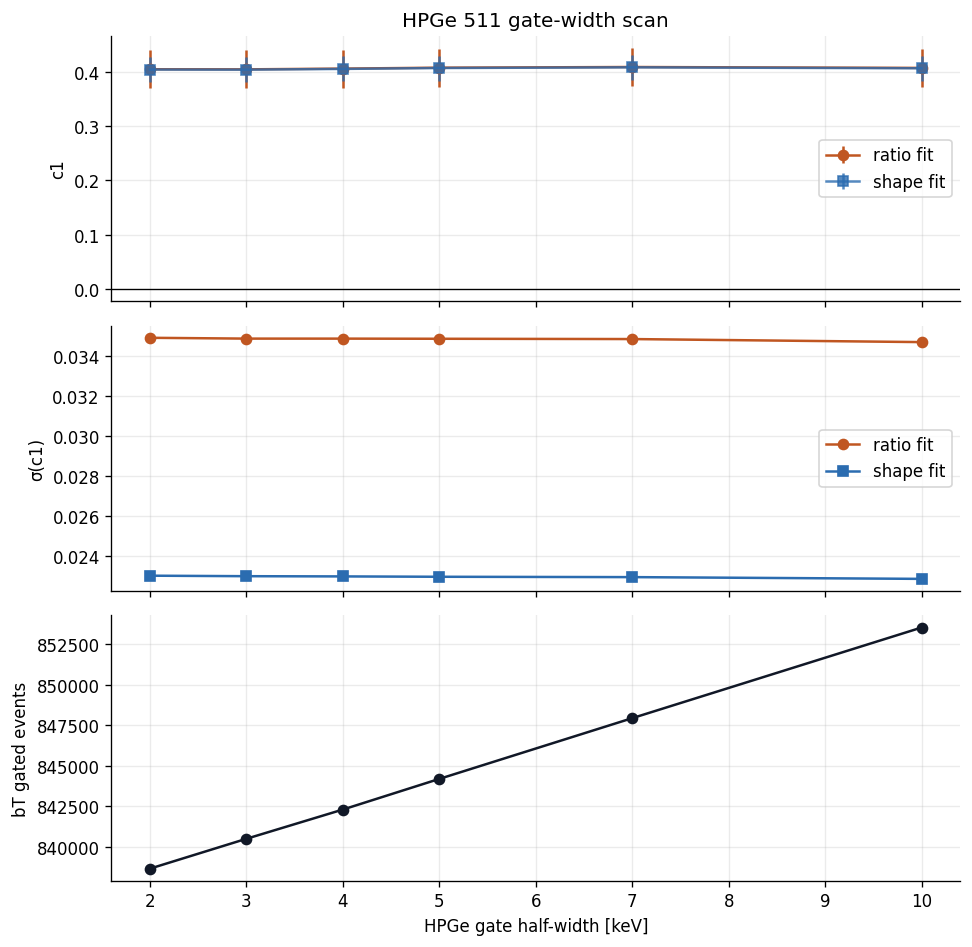

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8.2, 8), sharex=True)
gx = gate_scan["gate_half_width_keV"].to_numpy()
axes[0].errorbar(gx, gate_scan["ratio_c1"], yerr=gate_scan["ratio_c1_err"], fmt="o-", color="#c05621", label="ratio fit")
axes[0].errorbar(gx, gate_scan["shape_c1"], yerr=gate_scan["shape_c1_err"], fmt="s-", color="#2b6cb0", label="shape fit", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("c1")
axes[0].legend()
axes[0].set_title("HPGe 511 gate-width scan")

axes[1].plot(gx, gate_scan["ratio_c1_err"], "o-", color="#c05621", label="ratio fit")
axes[1].plot(gx, gate_scan["shape_c1_err"], "s-", color="#2b6cb0", label="shape fit")
axes[1].set_ylabel("σ(c1)")
axes[1].legend()

axes[2].plot(gx, gate_scan["bT_gated_events"], "o-", color="#111827")
axes[2].set_xlabel("HPGe gate half-width [keV]")
axes[2].set_ylabel("bT gated events")
fig.tight_layout()
savefig(fig, "hpge_gate_width_scan.png")
plt.show()

## 2D Cross-Check Using `(SiLi_1, SiLi_2)`

The naive 2D fit can give a misleadingly precise and biased result because it treats many sparse 2D bins as independent information. This section treats the 2D fit as a robustness diagnostic, not as the default result.

Safeguards used here:
- Symmetrize `SiLi_1` and `SiLi_2` to remove detector-label fluctuations.
- Include `b0` and `b1` template statistical uncertainty in the fit denominator.
- Scan 2D bin widths and minimum bin-count thresholds.

A 2D result is only credible if `c1` is stable across these harmless analysis choices. In this dataset the fine-bin 2D result is not used as an improvement because it shifts with binning; the coarser 20 keV version is kept only as a cross-check.

In [12]:
def symmetrize_hist2d(h: np.ndarray, v: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Symmetrize under SiLi_1 <-> SiLi_2. Variances add for the averaged counts."""
    return 0.5 * (h + h.T), 0.25 * (v + v.T)


def shape_fit_with_template_stats(
    h0: np.ndarray,
    v0: np.ndarray,
    h1: np.ndarray,
    v1: np.ndarray,
    hT: np.ndarray,
    vT: np.ndarray,
    mask: np.ndarray,
    iterations: int = 5,
) -> dict:
    p0, vp0, n0 = normalize_in_mask(h0, v0, mask)
    p1, vp1, n1 = normalize_in_mask(h1, v1, mask)
    pT, vpT, nT = normalize_in_mask(hT, vT, mask)
    good = mask & (p0 > 0) & (p1 > 0) & (pT > 0)
    c1 = 0.0
    fit = None
    for _ in range(iterations):
        sigma = np.sqrt(np.maximum(vpT + ((1.0 - c1) ** 2) * vp0 + (c1**2) * vp1, 1e-30))
        fit = constrained_fit(pT, p0, p1, sigma, good)
        c1 = fit["c1"]
    sigma = np.sqrt(np.maximum(vpT + ((1.0 - c1) ** 2) * vp0 + (c1**2) * vp1, 1e-30))
    fit = constrained_fit(pT, p0, p1, sigma, good)
    fit.update({"p0": p0, "p1": p1, "pT": pT, "sigma": sigma, "n0_fit": n0, "n1_fit": n1, "nT_fit": nT})
    return fit


def fit_2d_variant(bin_width: float, min_bin_count: float, symmetrize: bool = True) -> dict:
    bins = np.arange(SILI_2D_RANGE[0], SILI_2D_RANGE[1] + bin_width, bin_width)
    centers = 0.5 * (bins[:-1] + bins[1:])
    local = {}
    for label in ["b0", "b1", "bT"]:
        h, v, n = hist2d(samples[label], DEFAULT_GATE_HALF_WIDTH, bins=bins)
        if symmetrize:
            h, v = symmetrize_hist2d(h, v)
        local[label] = {"h": h, "v": v, "n": n}

    x, y = np.meshgrid(centers, centers, indexing="ij")
    raw_mask = (
        ((x + y) >= FIT_RANGE[0])
        & ((x + y) <= FIT_RANGE[1])
        & (local["b0"]["h"] >= min_bin_count)
        & (local["b1"]["h"] >= min_bin_count)
        & (local["bT"]["h"] >= min_bin_count)
    )
    if np.count_nonzero(raw_mask) < 20:
        return {
            "bin_width_keV": bin_width,
            "min_bin_count": min_bin_count,
            "symmetrized": symmetrize,
            "c1": np.nan,
            "c1_err": np.nan,
            "chi2_ndf": np.nan,
            "fit_bins": int(np.count_nonzero(raw_mask)),
            "status": "too_few_bins",
        }
    fit = shape_fit_with_template_stats(
        local["b0"]["h"].ravel(), local["b0"]["v"].ravel(),
        local["b1"]["h"].ravel(), local["b1"]["v"].ravel(),
        local["bT"]["h"].ravel(), local["bT"]["v"].ravel(),
        raw_mask.ravel(),
    )
    return {
        "bin_width_keV": bin_width,
        "min_bin_count": min_bin_count,
        "symmetrized": symmetrize,
        "c1": fit["c1"],
        "c1_err": fit["c1_err"],
        "c0": fit["c0"],
        "chi2_ndf": fit["chi2_ndf"],
        "fit_bins": int(np.count_nonzero(fit["mask"])),
        "status": "ok",
    }

# Keep the previous naive result visible as a warning/regression test.
hists2d = {}
for label in ["b0", "b1", "bT"]:
    h, v, n = hist2d(samples[label], DEFAULT_GATE_HALF_WIDTH)
    hists2d[label] = {"h": h, "v": v, "n": n}

H0 = hists2d["b0"]["h"]
H1 = hists2d["b1"]["h"]
HT = hists2d["bT"]["h"]
V0 = hists2d["b0"]["v"]
V1 = hists2d["b1"]["v"]
VT = hists2d["bT"]["v"]

X, Y = np.meshgrid(CENTERS_2D, CENTERS_2D, indexing="ij")
naive_2d_mask = ((X + Y) >= FIT_RANGE[0]) & ((X + Y) <= FIT_RANGE[1]) & (HT > 0) & (H0 > 0) & (H1 > 0)
naive_p0, naive_vp0, _ = normalize_in_mask(H0.ravel(), V0.ravel(), naive_2d_mask.ravel())
naive_p1, naive_vp1, _ = normalize_in_mask(H1.ravel(), V1.ravel(), naive_2d_mask.ravel())
naive_pT, naive_vpT, _ = normalize_in_mask(HT.ravel(), VT.ravel(), naive_2d_mask.ravel())
naive_sigma = np.sqrt(np.maximum(naive_vpT, 1e-30))
naive_fit2d = constrained_fit(naive_pT, naive_p0, naive_p1, naive_sigma, naive_2d_mask.ravel())

robust_default_2d = fit_2d_variant(20.0, min_bin_count=25, symmetrize=True)

fit2d_summary = pl.DataFrame([
    {
        "fit": "naive_2d_target_stats_only_do_not_use",
        "c1": naive_fit2d["c1"],
        "c1_err": naive_fit2d["c1_err"],
        "chi2_ndf": naive_fit2d["chi2_ndf"],
        "fit_bins": int(np.count_nonzero(naive_fit2d["mask"])),
        "status": "rejected_sparse_template_stats_missing",
    },
    {
        "fit": "robust_2d_sym_template_stats_20keV_min25",
        "c1": robust_default_2d["c1"],
        "c1_err": robust_default_2d["c1_err"],
        "chi2_ndf": robust_default_2d["chi2_ndf"],
        "fit_bins": robust_default_2d["fit_bins"],
        "status": robust_default_2d["status"],
    },
])
fit2d_summary

fit,c1,c1_err,chi2_ndf,fit_bins,status
str,f64,f64,f64,i64,str
"""naive_2d_target_stats_only_do_…",0.393143,0.016482,0.666887,1346,"""rejected_sparse_template_stats…"
"""robust_2d_sym_template_stats_2…",0.396548,0.019716,0.443494,298,"""ok"""


In [13]:
variant_rows = []
for bin_width in [10.0, 15.0, 20.0, 25.0, 30.0, 40.0]:
    for min_count in [1, 5, 10, 25, 50, 100]:
        variant_rows.append(fit_2d_variant(bin_width, min_count, symmetrize=True))
fit2d_scan = pl.DataFrame(variant_rows)
fit2d_scan

bin_width_keV,min_bin_count,symmetrized,c1,c1_err,c0,chi2_ndf,fit_bins,status
f64,i64,bool,f64,f64,f64,f64,i64,str
10.0,1,true,0.389969,0.016862,0.610031,0.459003,1340,"""ok"""
10.0,5,true,0.389584,0.01702,0.610416,0.496159,1208,"""ok"""
10.0,10,true,0.388433,0.017171,0.611567,0.518124,1136,"""ok"""
10.0,25,true,0.390213,0.017591,0.609787,0.565211,971,"""ok"""
10.0,50,true,0.388257,0.018091,0.611743,0.601598,817,"""ok"""
…,…,…,…,…,…,…,…,…
40.0,5,true,0.393665,0.020553,0.606335,0.361749,88,"""ok"""
40.0,10,true,0.393665,0.020553,0.606335,0.361749,88,"""ok"""
40.0,25,true,0.393665,0.020553,0.606335,0.361749,88,"""ok"""


/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/sili_2d_stability_scan.png


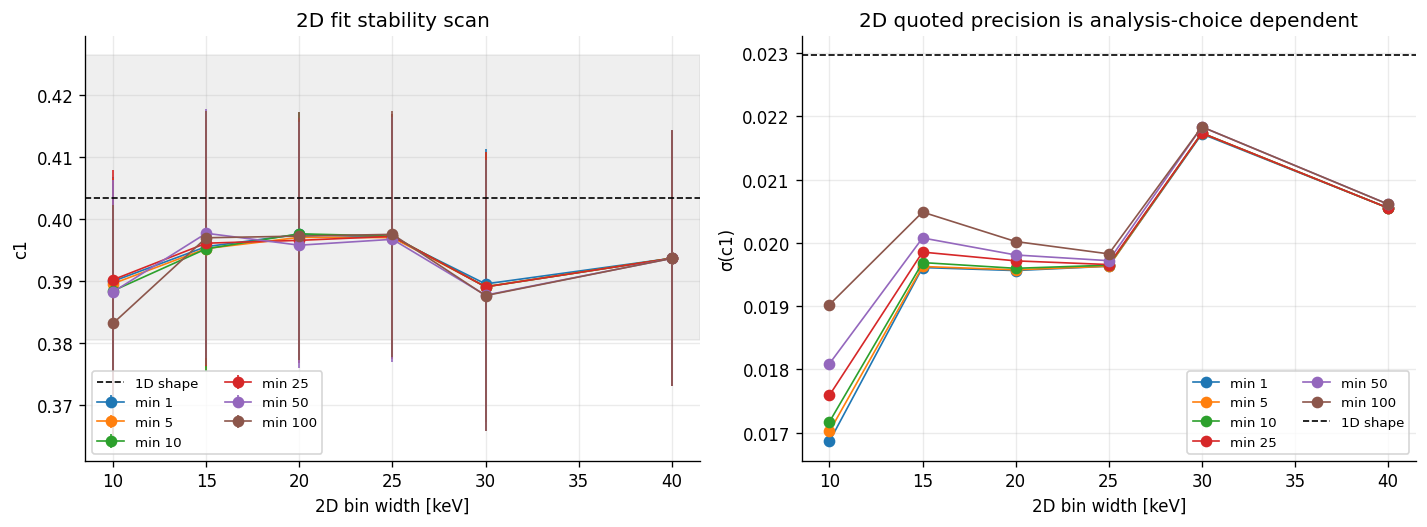

In [14]:
scan_ok = fit2d_scan.filter(pl.col("status") == "ok")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for min_count in sorted(scan_ok["min_bin_count"].unique().to_list()):
    part = scan_ok.filter(pl.col("min_bin_count") == min_count).sort("bin_width_keV")
    axes[0].errorbar(
        part["bin_width_keV"],
        part["c1"],
        yerr=part["c1_err"],
        marker="o",
        linewidth=1.0,
        label=f"min {int(min_count)}",
    )
axes[0].axhline(baseline_shape["c1"], color="black", linestyle="--", linewidth=1.0, label="1D shape")
axes[0].axhspan(
    baseline_shape["c1"] - baseline_shape["c1_err"],
    baseline_shape["c1"] + baseline_shape["c1_err"],
    color="grey",
    alpha=0.12,
)
axes[0].set_xlabel("2D bin width [keV]")
axes[0].set_ylabel("c1")
axes[0].set_title("2D fit stability scan")
axes[0].legend(fontsize=8, ncol=2)

for min_count in sorted(scan_ok["min_bin_count"].unique().to_list()):
    part = scan_ok.filter(pl.col("min_bin_count") == min_count).sort("bin_width_keV")
    axes[1].plot(part["bin_width_keV"], part["c1_err"], marker="o", linewidth=1.0, label=f"min {int(min_count)}")
axes[1].axhline(baseline_shape["c1_err"], color="black", linestyle="--", linewidth=1.0, label="1D shape")
axes[1].set_xlabel("2D bin width [keV]")
axes[1].set_ylabel("σ(c1)")
axes[1].set_title("2D quoted precision is analysis-choice dependent")
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
savefig(fig, "sili_2d_stability_scan.png")
plt.show()

/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/sili_2d_diagnostic_do_not_use_as_primary.png


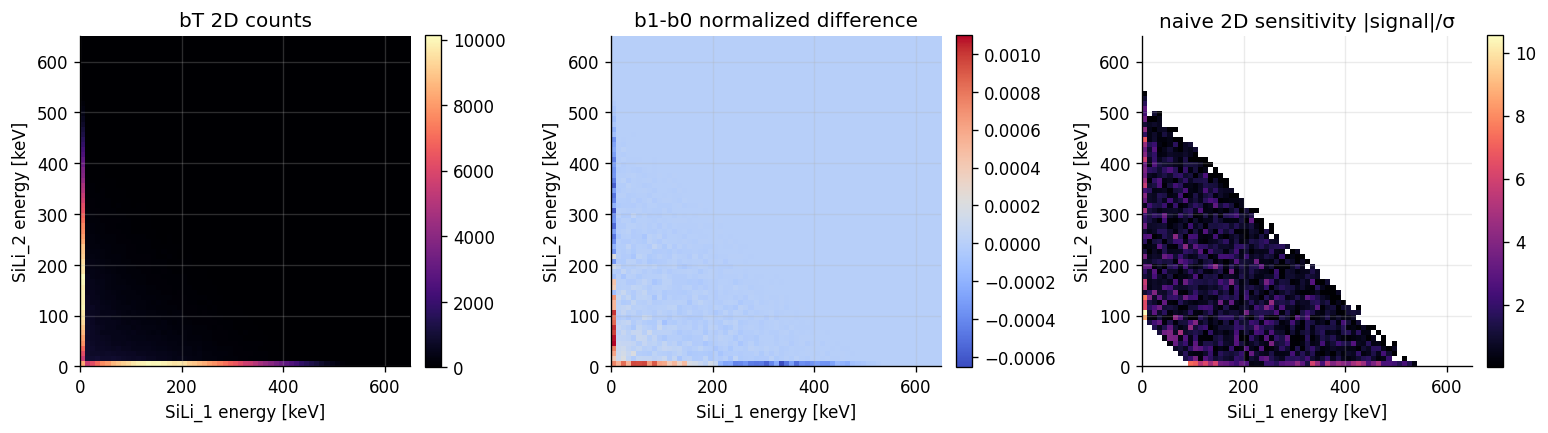

In [15]:
# Diagnostic image for the default 2D binning. This is for visual QA only, not a recommended fit result.
sens2d = np.full_like(HT, np.nan, dtype=float)
flat_sens = np.abs((naive_p1 - naive_p0) / naive_sigma)
sens2d.ravel()[naive_fit2d["mask"]] = flat_sens[naive_fit2d["mask"]]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title in [
    (axes[0], HT, "bT 2D counts"),
    (axes[1], (H1 / max(H1.sum(), 1)) - (H0 / max(H0.sum(), 1)), "b1-b0 normalized difference"),
    (axes[2], sens2d, "naive 2D sensitivity |signal|/σ"),
]:
    im = ax.imshow(
        data.T,
        origin="lower",
        extent=[BINS_2D[0], BINS_2D[-1], BINS_2D[0], BINS_2D[-1]],
        aspect="equal",
        cmap="magma" if ax is not axes[1] else "coolwarm",
    )
    ax.set_xlabel("SiLi_1 energy [keV]")
    ax.set_ylabel("SiLi_2 energy [keV]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
savefig(fig, "sili_2d_diagnostic_do_not_use_as_primary.png")
plt.show()

## Template-Statistics Diagnostic

This estimates how much the ratio-fit uncertainty would improve if the `b0` and `b1` template statistics were increased while keeping `bT` fixed.

In [16]:
scale_rows = []
for scale in [1, 2, 5, 10, 20, 50]:
    rf = ratio_fit(
        hists["b0"]["h"], hists["b0"]["v"],
        hists["b1"]["h"], hists["b1"]["v"],
        hists["bT"]["h"], hists["bT"]["v"],
        fit_mask,
        include_template_stats=True,
        template_stat_scale=float(scale),
    )
    scale_rows.append({
        "template_stat_scale": scale,
        "ratio_c1": rf["c1"],
        "ratio_c1_err": rf["c1_err"],
        "relative_to_current_err": rf["c1_err"] / baseline_ratio_with_templates["c1_err"],
    })
template_scale_scan = pl.DataFrame(scale_rows)
template_scale_scan

template_stat_scale,ratio_c1,ratio_c1_err,relative_to_current_err
i64,f64,f64,f64
1,0.403953,0.034863,1.0
2,0.403761,0.029522,0.846792
5,0.403572,0.02579,0.739754
10,0.403488,0.024419,0.700435
20,0.403441,0.023704,0.679919
50,0.40341,0.023264,0.667304


/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/template_statistics_projection.png


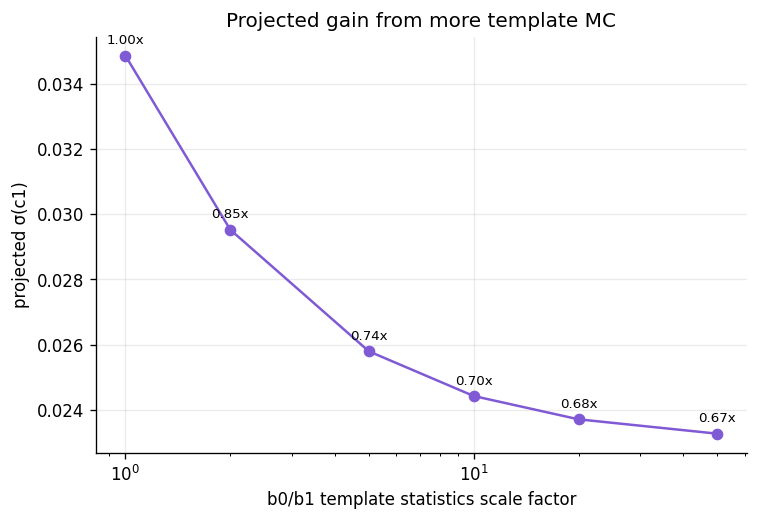

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(template_scale_scan["template_stat_scale"], template_scale_scan["ratio_c1_err"], "o-", color="#805ad5")
ax.set_xscale("log")
ax.set_xlabel("b0/b1 template statistics scale factor")
ax.set_ylabel("projected σ(c1)")
ax.set_title("Projected gain from more template MC")
for row in template_scale_scan.iter_rows(named=True):
    ax.annotate(f"{row['relative_to_current_err']:.2f}x", (row["template_stat_scale"], row["ratio_c1_err"]), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
savefig(fig, "template_statistics_projection.png")
plt.show()

## Summary and Exports

The table below collects the main candidates. The naive 2D fit is deliberately marked as rejected because it is not stable under statistically harmless choices. Prefer the 1D shape fit. The 2D section is a diagnostic cross-check, not the recommended result.

In [18]:
# Summarize 2D stability. Fine 10 keV bins are diagnostic only; they are not used as the recommended result.
ok_2d = fit2d_scan.filter(pl.col("status") == "ok")
if len(ok_2d) > 0:
    c1_spread = float(ok_2d["c1"].max() - ok_2d["c1"].min())
    median_err = float(ok_2d["c1_err"].median())
else:
    c1_spread = np.nan
    median_err = np.nan

summary_rows = [
    {
        "method": "baseline_shape_recommended",
        "c1": baseline_shape["c1"],
        "c1_err": baseline_shape["c1_err"],
        "chi2_ndf": baseline_shape["chi2_ndf"],
        "status": "recommended",
        "notes": "normalized SiLi-sum shape fit; stable and physically aligned with endpoint spectrum",
    },
    {
        "method": "baseline_ratio",
        "c1": baseline_ratio["c1"],
        "c1_err": baseline_ratio["c1_err"],
        "chi2_ndf": baseline_ratio["chi2_ndf"],
        "status": "cross_check",
        "notes": "ratio fit; lower normalization sensitivity but larger uncertainty",
    },
    {
        "method": "baseline_ratio_with_template_stats",
        "c1": baseline_ratio_with_templates["c1"],
        "c1_err": baseline_ratio_with_templates["c1_err"],
        "chi2_ndf": baseline_ratio_with_templates["chi2_ndf"],
        "status": "cross_check",
        "notes": "ratio fit with iterative template-stat variance",
    },
    {
        "method": "naive_2d_rejected",
        "c1": naive_fit2d["c1"],
        "c1_err": naive_fit2d["c1_err"],
        "chi2_ndf": naive_fit2d["chi2_ndf"],
        "status": "rejected",
        "notes": "sparse 2D bins and missing template-stat uncertainty bias the result",
    },
    {
        "method": "robust_2d_cross_check_20keV",
        "c1": robust_default_2d["c1"],
        "c1_err": robust_default_2d["c1_err"],
        "chi2_ndf": robust_default_2d["chi2_ndf"],
        "status": "diagnostic_only",
        "notes": f"symmetrized/template-stat 2D cross-check; not a precision gain; scan c1 spread={c1_spread:.4g}, median err={median_err:.4g}",
    },
]
main_summary = pl.DataFrame(summary_rows).with_columns(
    physical_b=pl.col("c1").map_elements(lambda x: physical_b_from_template_c(float(x), fierz_G), return_dtype=pl.Float64),
    physical_b_err=pl.struct(["c1", "c1_err"]).map_elements(
        lambda s: physical_b_error_from_template_c(float(s["c1"]), float(s["c1_err"]), fierz_G),
        return_dtype=pl.Float64,
    ),
)

main_summary.write_csv(FIG_DIR / "main_fit_optimization_summary.csv")
window_scan.write_csv(FIG_DIR / "fit_window_scan.csv")
gate_scan.write_csv(FIG_DIR / "hpge_gate_width_scan.csv")
template_scale_scan.write_csv(FIG_DIR / "template_statistics_projection.csv")
fit2d_summary.write_csv(FIG_DIR / "sili_2d_fit_summary.csv")
fit2d_scan.write_csv(FIG_DIR / "sili_2d_stability_scan.csv")

print(FIG_DIR / "main_fit_optimization_summary.csv")
print(FIG_DIR / "fit_window_scan.csv")
print(FIG_DIR / "hpge_gate_width_scan.csv")
print(FIG_DIR / "template_statistics_projection.csv")
print(FIG_DIR / "sili_2d_fit_summary.csv")
print(FIG_DIR / "sili_2d_stability_scan.csv")
main_summary

/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/main_fit_optimization_summary.csv
/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/fit_window_scan.csv
/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/hpge_gate_width_scan.csv
/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/template_statistics_projection.csv
/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/sili_2d_fit_summary.csv
/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/optimize_bT_mixture_fit/sili_2d_stability_scan.csv


method,c1,c1_err,chi2_ndf,status,notes,physical_b,physical_b_err
str,f64,f64,f64,str,str,f64,f64
"""baseline_shape_recommended""",0.403389,0.022966,1.574677,"""recommended""","""normalized SiLi-sum shape fit;…",0.28641,0.019504
"""baseline_ratio""",0.404899,0.032366,0.796143,"""cross_check""","""ratio fit; lower normalization…",0.287693,0.027526
"""baseline_ratio_with_template_s…",0.403953,0.034863,0.684255,"""cross_check""","""ratio fit with iterative templ…",0.286889,0.029623
"""naive_2d_rejected""",0.393143,0.016482,0.666887,"""rejected""","""sparse 2D bins and missing tem…",0.277752,0.013858
"""robust_2d_cross_check_20keV""",0.396548,0.019716,0.443494,"""diagnostic_only""","""symmetrized/template-stat 2D c…",0.28062,0.016633


## Practical Reading

Use this notebook in this order:

1. Treat the normalized 1D Si(Li)-sum shape fit as the baseline result.
2. Use the ratio fit as a normalization cross-check; in this dataset it increases the uncertainty.
3. Use the window scan to reject ranges with unstable `c1` or bad `χ²/ndf`.
4. Use the HPGe gate scan to choose a gate that minimizes `σ(c1)` without creating instability.
5. Do not use the naive 2D fit. It is included only to show why it fails.
6. Reconsider a 2D observable only after it passes the stability scan across bin width, count threshold, symmetrization, and template-stat uncertainty.
7. Use the template-statistics projection before spending more Geant4 time on `b0` and `b1`.
8. Read `physical_b`, not raw `c1`, when quoting a Fierz bound. `c1` is only the coordinate between normalized templates.
